# Decision Tree Classifier

**Dataset**: Iris — 150 samples, 4 features, 3 classes  
**Objective**: Build, train, and evaluate a Decision Tree classifier using comprehensive evaluation measures.

### How It Works

A Decision Tree recursively splits the data on the feature that best reduces impurity at each node:

$$\text{Gini}(t) = 1 - \sum_{k} p_k^2$$

| Term | Meaning |
|---|---|
| **Node** | A decision point — splits on one feature |
| **Leaf** | Terminal node — assigns a class label |
| **Gini Impurity** | Probability of misclassifying a random sample at a node |
| **max\_depth** | Limits tree depth to prevent overfitting |

.

| Section | Description |
|---|---|
| 1 | Data Loading & Exploration |
| 2 | Train / Test Split |
| 3 | Build & Train the Decision Tree |
| 4 | Evaluation Measures |
| 5 | Feature Importance |
| 6 | Tree Visualization |

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings('ignore')

print('All imports successful.')

All imports successful.


## 1. Data Loading & Exploration

In [8]:
data = load_iris()
X = data.data
y = data.target
feature_names = data.feature_names
class_names = data.target_names

df = pd.DataFrame(X, columns=feature_names)
df['species'] = [class_names[i] for i in y]

print('Shape          :', X.shape)
print('Features       :', list(feature_names))
print('Classes        :', list(class_names))
print('\nClass distribution:')
print(df['species'].value_counts())
print('\nDescriptive statistics:')
df.drop('species', axis=1).describe().round(2)

Shape          : (150, 4)
Features       : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes        : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Descriptive statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


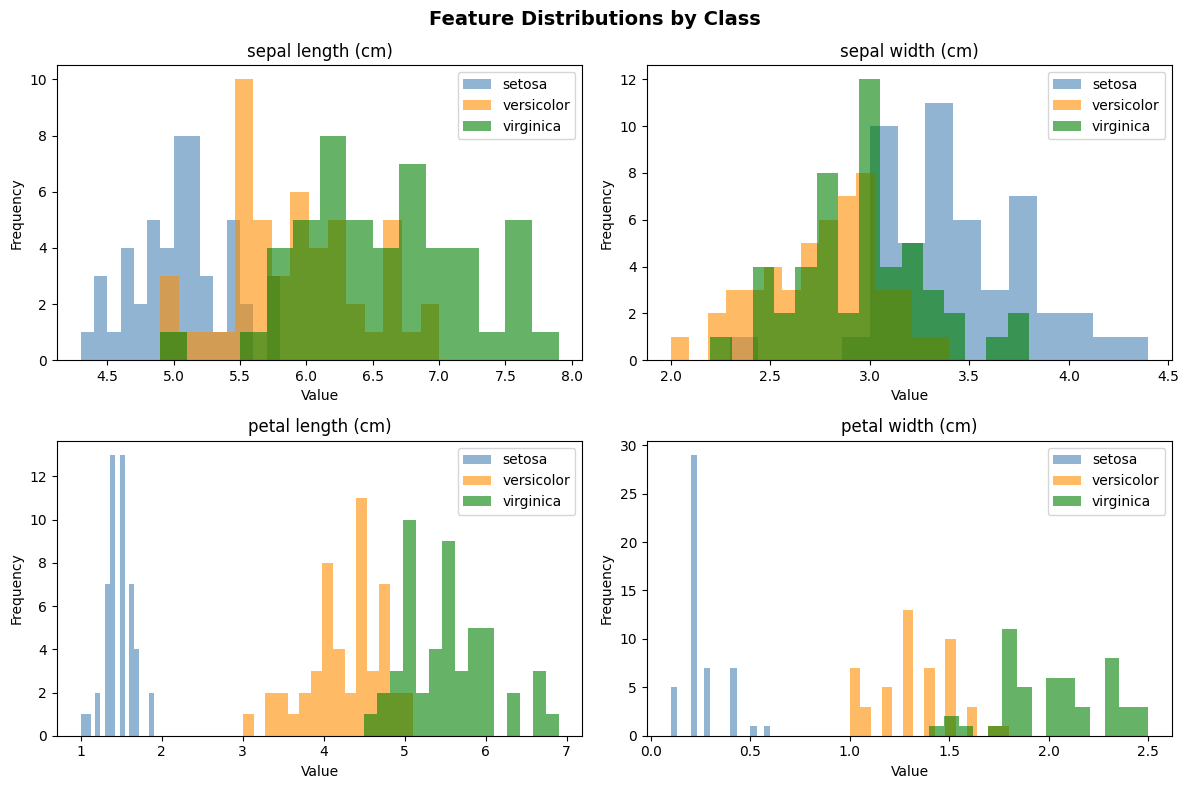

In [9]:
# Feature distributions per class
colors = ['steelblue', 'darkorange', 'green']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for idx, feature in enumerate(feature_names):
    ax = axes[idx // 2][idx % 2]
    for i, cls in enumerate(class_names):
        ax.hist(df[df['species'] == cls][feature], bins=15,
                alpha=0.6, color=colors[i], label=cls)
    ax.set_title(feature)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Feature Distributions by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Train / Test Split

`stratify=y` ensures each split preserves the original class proportions.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=99, stratify=y
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')

Training samples : 105
Testing  samples : 45


## 3. Build & Train the Decision Tree

Key hyperparameters:
- **criterion** `gini` — measures node impurity (alternative: `entropy`)
- **max_depth** — caps tree depth to prevent overfitting

In [11]:
clf = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=1)
clf.fit(X_train, y_train)

print('Decision Tree trained.')
print(f'  Criterion  : {clf.criterion}')
print(f'  Tree depth : {clf.get_depth()}')
print(f'  Leaf nodes : {clf.get_n_leaves()}')

Decision Tree trained.
  Criterion  : gini
  Tree depth : 4
  Leaf nodes : 8


## 4. Evaluation Measures

| Metric | What it captures |
|---|---|
| **Accuracy** | Overall fraction of correct predictions |
| **Confusion Matrix** | Per-class prediction breakdown |
| **Precision** | Of predicted positives, how many were actually positive |
| **Recall** | Of actual positives, how many were correctly found |
| **F1-Score** | Harmonic mean of precision and recall |
| **Cross-Validation** | Accuracy variance across multiple data splits |
| **ROC / AUC** | Discrimination power per class (one-vs-rest) |

Accuracy: 0.9778  (97.78%)



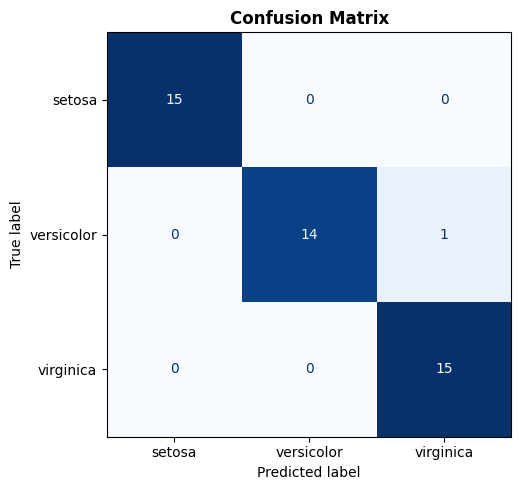

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.93      0.97        15
   virginica       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



In [12]:
y_pred = clf.predict(X_test)

# --- Accuracy ---
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}  ({accuracy * 100:.2f}%)\n')

# --- Confusion Matrix ---
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

# --- Precision / Recall / F1 ---
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=class_names))

5-Fold Stratified Cross-Validation:
  Scores per fold : [1.     0.9667 0.9333 0.9667 0.9   ]
  Mean accuracy   : 0.9533
  Std deviation   : 0.0340


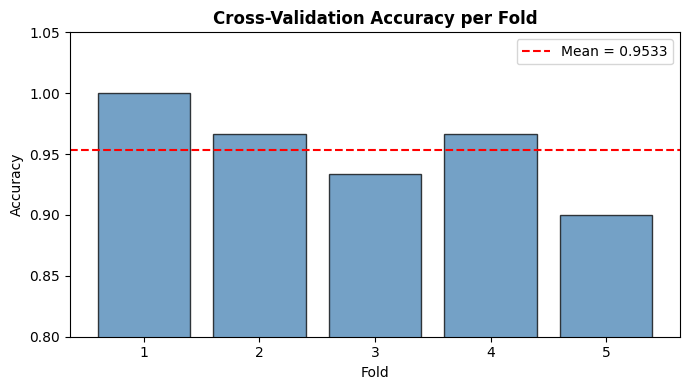

In [13]:
# --- Stratified 5-Fold Cross-Validation ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, X, y, cv=skf, scoring='accuracy')

print('5-Fold Stratified Cross-Validation:')
print(f'  Scores per fold : {cv_scores.round(4)}')
print(f'  Mean accuracy   : {cv_scores.mean():.4f}')
print(f'  Std deviation   : {cv_scores.std():.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 6), cv_scores, color='steelblue', alpha=0.75, edgecolor='black')
ax.axhline(cv_scores.mean(), color='red', linestyle='--',
           label=f'Mean = {cv_scores.mean():.4f}')
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.8, 1.05)
ax.set_title('Cross-Validation Accuracy per Fold', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

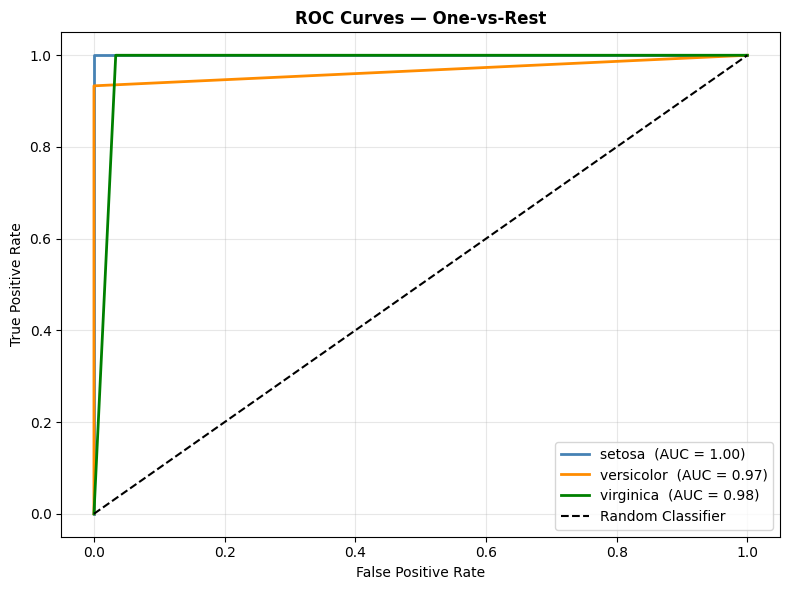

In [14]:
# --- ROC Curves (One-vs-Rest) ---
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = clf.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['steelblue', 'darkorange', 'green']

for i, (cls, color) in enumerate(zip(class_names, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{cls}  (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — One-vs-Rest', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Feature Importance

Each feature is scored by the total Gini impurity reduction it contributes across all splits.

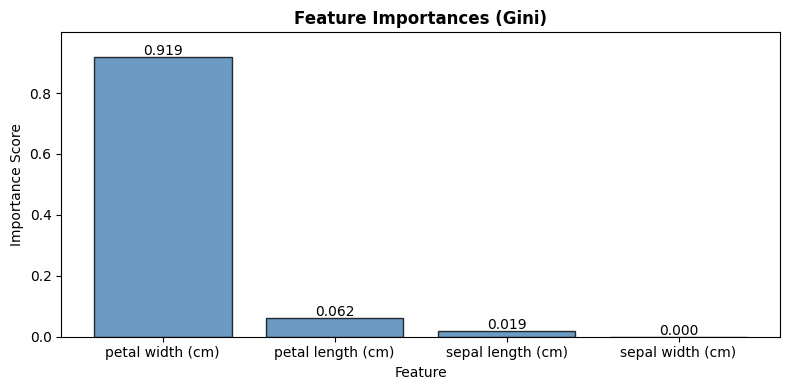

In [15]:
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in indices]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(sorted_features, importances[indices],
              color='steelblue', alpha=0.8, edgecolor='black')
for bar, val in zip(bars, importances[indices]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.005,
            f'{val:.3f}', ha='center', fontsize=10)
ax.set_title('Feature Importances (Gini)', fontweight='bold')
ax.set_ylabel('Importance Score')
ax.set_xlabel('Feature')
ax.set_ylim(0, importances.max() + 0.08)
plt.tight_layout()
plt.show()

## 6. Tree Visualization

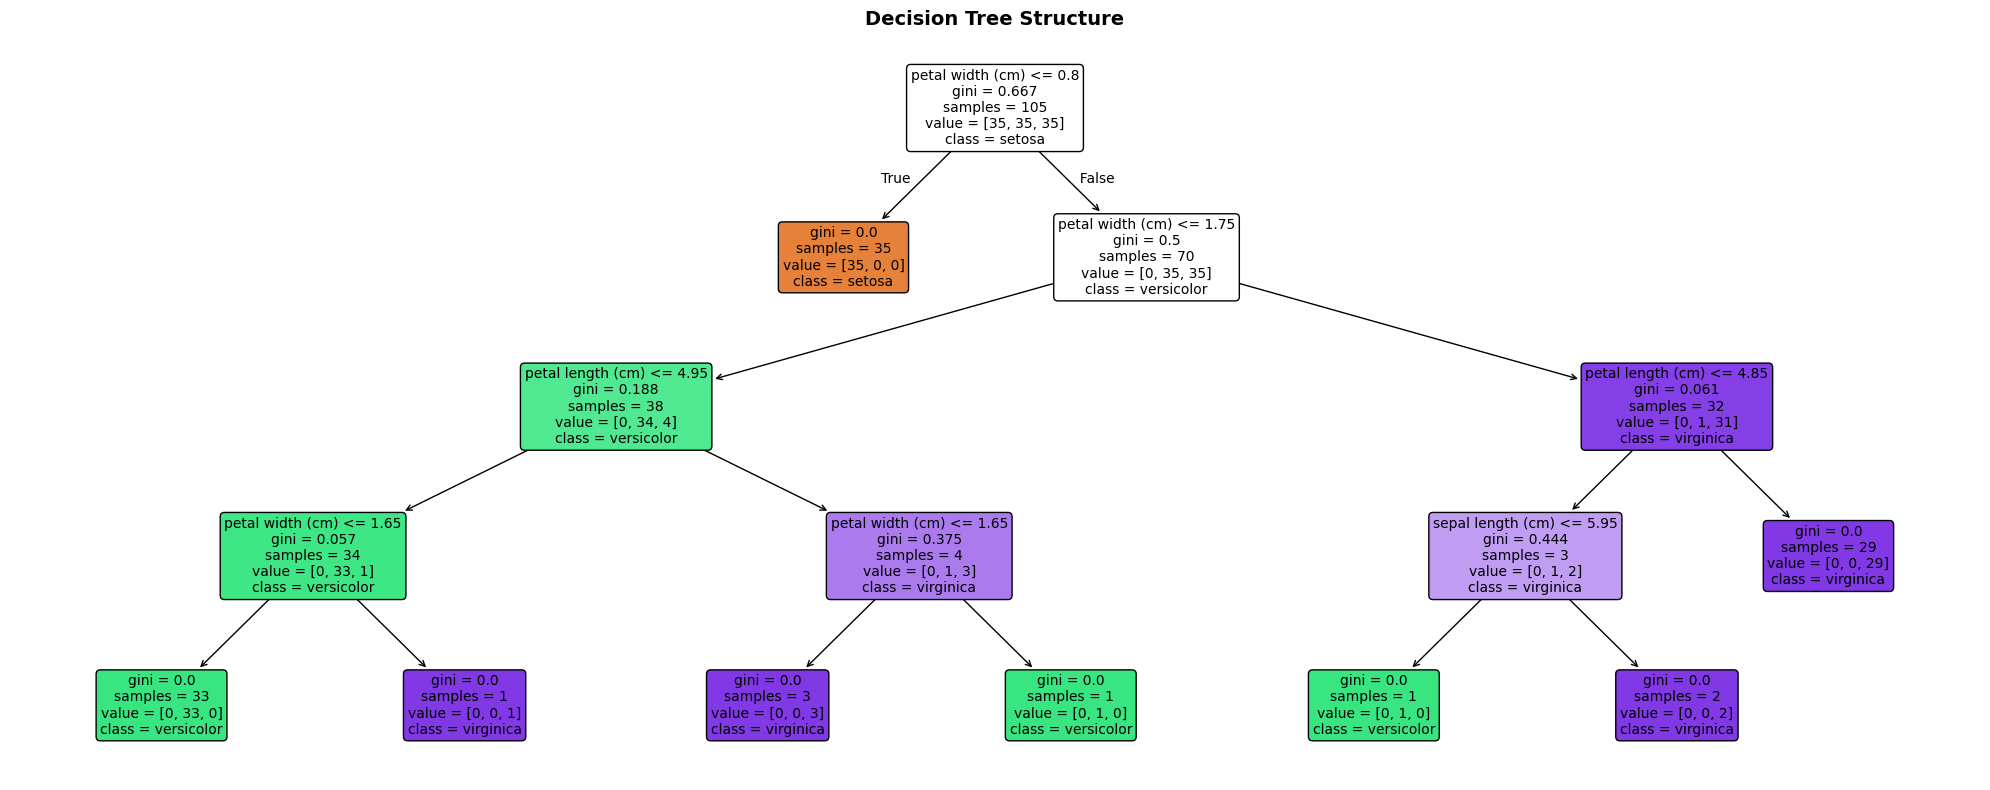

Text Representation:
|--- petal width (cm) <= 0.80
|   |--- class: 0
|--- petal width (cm) >  0.80
|   |--- petal width (cm) <= 1.75
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- petal width (cm) <= 1.65
|   |   |   |   |--- class: 1
|   |   |   |--- petal width (cm) >  1.65
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- petal width (cm) <= 1.65
|   |   |   |   |--- class: 2
|   |   |   |--- petal width (cm) >  1.65
|   |   |   |   |--- class: 1
|   |--- petal width (cm) >  1.75
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- sepal length (cm) <= 5.95
|   |   |   |   |--- class: 1
|   |   |   |--- sepal length (cm) >  5.95
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



In [16]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    clf,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)
ax.set_title('Decision Tree Structure', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Text Representation:')
print(export_text(clf, feature_names=list(feature_names)))

## Summary

**Key results** (run all cells to populate exact values):

| Metric | Interpretation |
|---|---|
| Hold-out test accuracy | Single-split estimate on 30% test data |
| **5-Fold CV mean accuracy** | Reliable generalisation estimate |
| **5-Fold CV std dev** | Low std → model is stable across splits |
| Mean AUC (one-vs-rest) | Near 1.0 → excellent class separation |

**Why the Decision Tree works well on Iris:**
- Petal length and petal width are highly discriminative (visible in Feature Importance)
- A shallow tree (`max_depth=4`) is sufficient — deeper trees would overfit
- CV confirms the high accuracy is consistent, not a result of a lucky train/test split
- The tree structure (Section 6) is fully interpretable — every decision path can be read directly